<a href="https://colab.research.google.com/github/Haku-333/plant-disease-detection/blob/main/plantdiseasedetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================
# 1. IMPORT LIBRARIES
# ============================================

import os
from google.colab import userdata

os.environ["pranaynyachhyon"] = 'pranaynyachhyon'
os.environ["KGAT_a4a96d80705d0619905e1386d8a79d11"] = 'KGAT_a4a96d80705d0619905e1386d8a79d11'

!pip install kagglehub
import kagglehub

path = kagglehub.dataset_download("vipoooool/new-plant-diseases-dataset")
print("downloaded to:", path)

# See the folder structure
for root, dirs, files in os.walk(path):
    print(root)
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing import image



Using Colab cache for faster access to the 'new-plant-diseases-dataset' dataset.
downloaded to: /kaggle/input/new-plant-diseases-dataset
/kaggle/input/new-plant-diseases-dataset
/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)
/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)
/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid
/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid/Tomato___Late_blight
/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid/Tomato___healthy
/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid/Grape___healthy
/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/N

In [ ]:
# ============================================
# 2. DATASET PATHS
# ============================================

TRAIN_DIR ="/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train"
VALID_DIR = "/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid"

IMG_SIZE = 224
BATCH_SIZE = 32

# ============================================
# 3. LOAD DATASET
# ============================================

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VALID_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

# Save class names
class_names = train_ds.class_names
print("Total Classes:", len(class_names))

# Prefetch for faster training
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)



Found 70295 files belonging to 38 classes.
Found 17572 files belonging to 38 classes.
Total Classes: 38


In [ ]:
class_names

['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_

In [ ]:
# ============================================
# 4. BUILD MODEL (EfficientNetB0)
# ============================================

def build_model(num_classes):

    base_model = EfficientNetB0(
        weights="imagenet",
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    base_model.trainable = False

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation="softmax")
    ])

    return model


model = build_model(len(class_names))

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()



16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 38)             │        48,678 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,103,369 (15.65 MB)

 Trainable params: 51,238 (200.15 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [ ]:
# ============================================
# 5. CALLBACKS
# ============================================

callbacks = [

    tf.keras.callbacks.ModelCheckpoint(
        "best_plant_model.keras",
        save_best_only=True
    ),

    tf.keras.callbacks.EarlyStopping(
        patience=3,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2
    )
]

# ============================================
# 6. PHASE 1 TRAINING
# ============================================

print("Phase 1 Training...")

model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=callbacks
)

# ============================================
# 7. PHASE 2 FINE TUNING
# ============================================

print("Phase 2 Fine Tuning...")

model.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)



Phase 1 Training...
Epoch 1/5
1703/2197 ━━━━━━━━━━━━━━━━━━━━ 17:20 2s/step - accuracy: 0.8000 - loss: 0.7337

Model Saved Successfully!


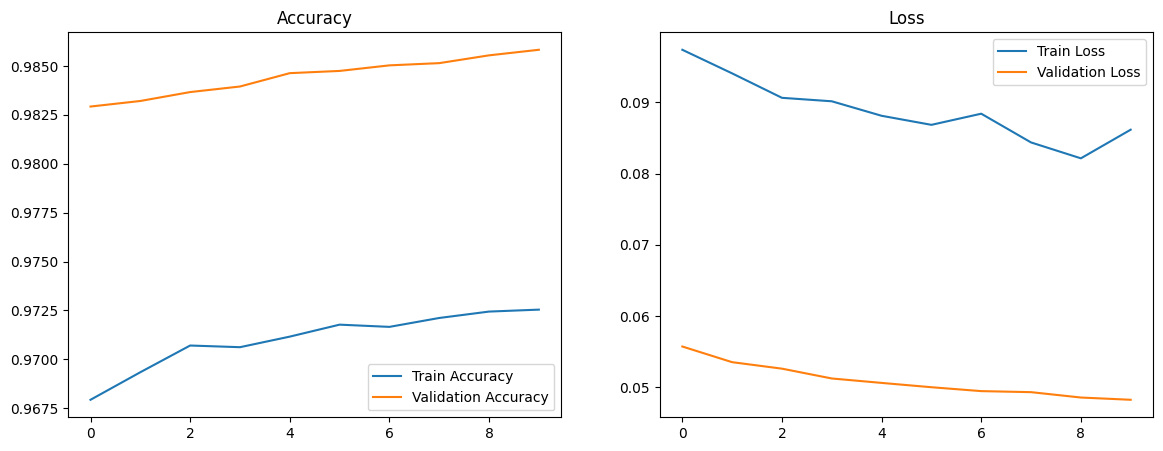

In [ ]:
# ============================================
# 8. SAVE MODEL
# ============================================

model.save("final_plant_disease_model.h5")

print("Model Saved Successfully!")

# ============================================
# 9. PLOT TRAINING RESULTS
# ============================================

def plot_results(history):

    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]

    loss = history.history["loss"]
    val_loss = history.history["val_loss"]

    epochs = range(len(acc))

    plt.figure(figsize=(14,5))

    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(epochs, acc, label="Train Accuracy")
    plt.plot(epochs, val_acc, label="Validation Accuracy")
    plt.legend()
    plt.title("Accuracy")

    # Loss
    plt.subplot(1,2,2)
    plt.plot(epochs, loss, label="Train Loss")
    plt.plot(epochs, val_loss, label="Validation Loss")
    plt.legend()
    plt.title("Loss")

    plt.show()

plot_results(history)



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


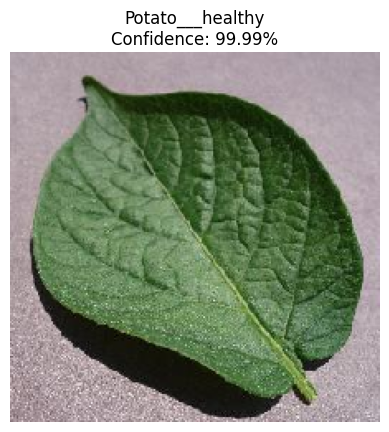

Prediction: Potato___healthy
Confidence: 99.98503


In [ ]:
# ============================================
# 10. PREDICT TEST IMAGE
# ============================================

def predict_disease(img_path):

    img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))

    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)

    predicted_index = np.argmax(prediction[0])
    predicted_class = class_names[predicted_index]

    confidence = prediction[0][predicted_index] * 100

    plt.imshow(img)
    plt.title(f"{predicted_class}\nConfidence: {confidence:.2f}%")
    plt.axis("off")
    plt.show()

    print("Prediction:", predicted_class)
    print("Confidence:", confidence)

# ============================================
# 11. TEST IMAGE
# ============================================

test_image = "/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/test/test/PotatoHealthy1.JPG"

predict_disease(test_image)